# NutriWise — Semantic Embedding Re-Ranker
### Baseline (Fuzzy) vs. Advanced (Embeddings) for food matching

**Problem.** NutriWise reads receipt lines (e.g. `"Bio BB Feta 200g"`) and must find the matching
nutrition entry in the **BLS 4.0 table**. Today's resolver uses fuzzy string matching, among other things.
We test whether a **multilingual sentence-embedding model** (`paraphrase-multilingual-MiniLM`) matches better.

**No trained model.** We *train nothing* — we use a pre-trained embedding model for inference and **measure**
it against the fuzzy baseline on the same test set. Honesty as a feature.

---
## Step 0 — Methodology (the core hurdle)

The evaluation dataset `bls_off_judgments.json` (76 items, 227 occurrences, 3-LLM judge panel) labels only
whether **one** top-1 pick was correct per item — it is **not a fully labelled candidate list**.

**Our honest solution (gold standard = verified BLS matches):**
- **Query** = `normalized_name` (the cleaned receipt line).
- **Gold target** = `bls_matched_name`, but **only** for items the judges confirmed as `correct` or
  `partially_correct`. That name *is* a real BLS entry, so it lives inside the corpus.
- **Corpus** = all food names in the BLS 4.0 table.

> **What is "gold"?** The gold standard (ground truth) is the known-correct reference answer we measure
> against. Here: the receipt line is the query, and the judge-confirmed BLS entry is the gold answer.

**Baseline (Fuzzy):** rank the BLS names by string similarity to the query, take top-1.
**Advanced (Embeddings):** embed the query + all BLS names, rank by cosine similarity, take top-1.

**Metrics (same set for both):** top-1 accuracy, Recall@3, Recall@5, mean/median rank of the gold hit.

> **Limits (honest up front):** 76 items is a small dataset; there are no fresh judge verdicts for picks
> that differ from the known ones. This is a retrieval benchmark against known gold answers, not a new
> qualitative assessment.

---
## Step 1 — Setup & configuration

Dependencies (once, from the repo root):
```bash
python -m pip install -r ml/requirements-ml.txt
```
> Tip: use `python -m pip` (not just `pip`) so packages land in **exactly the** venv the notebook runs in —
> otherwise they may end up in a neighbouring project's venv.

In [1]:
from pathlib import Path

# Paths relative to the repo root (notebook lives in ml/)
REPO = Path.cwd().parent if Path.cwd().name == "ml" else Path.cwd()
JUDGMENTS = REPO / "bls_off_judgments.json"
BLS_XLSX  = REPO / "BLS_data" / "BLS_4_0_Daten_2025_DE.xlsx"

# Model for the advanced re-ranker (multilingual, small, CPU-friendly)
EMBED_MODEL = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

# Verdicts that count as gold standard (confirmed by the judges)
GOLD_VERDICTS = {"correct", "partially_correct"}

assert JUDGMENTS.exists(), f"Judge dataset missing: {JUDGMENTS}"
assert BLS_XLSX.exists(),  f"BLS table missing: {BLS_XLSX}"
print("Repo:", REPO)
print("Judge dataset:", JUDGMENTS.name, "OK")
print("BLS table:", BLS_XLSX.name, "OK")

Repo: /Users/jenniferrake/Desktop/GitHub_Bootcamp/LLM
Judge dataset: bls_off_judgments.json OK
BLS table: BLS_4_0_Daten_2025_DE.xlsx OK


In [2]:
# Import check: fails early with a clear message if a dependency is missing.
import importlib.util

REQUIRED = ["pandas", "openpyxl", "rapidfuzz", "sentence_transformers", "sklearn", "matplotlib"]
missing = [m for m in REQUIRED if importlib.util.find_spec(m) is None]
if missing:
    raise ImportError(
        f"Missing packages: {missing}\n"
        f"Please run:  python -m pip install -r ml/requirements-ml.txt"
    )
print("All dependencies present.")

All dependencies present.


---
## Step 2 — Load data, build gold set & EDA

We load both sources, build the **evaluation set** (gold standard) and check integrity:
1. **Judge dataset** → one DataFrame row per item.
2. **BLS corpus** → all 7140 food names (`Lebensmittelbezeichnung`) — the candidate pool.
3. **Gold set** = items with `bls_verdict ∈ {correct, partially_correct}` and a present `bls_matched_name`.
   For these we know the correct BLS answer and can measure retrieval.
4. **Integrity check:** every gold name must live in the corpus — otherwise no matcher could ever find it.

In [3]:
import json
import pandas as pd

# 1) Judge dataset
with open(JUDGMENTS, encoding="utf-8") as f:
    judgments = json.load(f)
df = pd.DataFrame(judgments)
print(f"Judge dataset: {len(df)} items, {df['occurrences'].sum()} occurrences")

# 2) BLS corpus (candidate pool)
bls = pd.read_excel(BLS_XLSX)
NAME_COL = "Lebensmittelbezeichnung"          # German food name column
corpus_names = bls[NAME_COL].dropna().astype(str).str.strip()
corpus_names = corpus_names[corpus_names != ""].drop_duplicates().reset_index(drop=True)
corpus_set = set(corpus_names)
print(f"BLS corpus: {len(corpus_names)} unique food names")

Judge dataset: 76 items, 227 occurrences


BLS corpus: 7140 unique food names


In [4]:
# 3) Gold set: items with a judge-confirmed BLS match
gold = df[df["bls_verdict"].isin(GOLD_VERDICTS) & df["bls_matched_name"].notna()].copy()
gold["query"] = gold["normalized_name"].astype(str).str.strip()
gold["gold_name"] = gold["bls_matched_name"].astype(str).str.strip()

# 4) Integrity check: every gold name must be in the corpus
in_corpus = gold["gold_name"].isin(corpus_set)
if not in_corpus.all():
    missing_names = gold.loc[~in_corpus, "gold_name"].tolist()
    raise AssertionError(f"{len(missing_names)} gold names missing from corpus: {missing_names}")

gold = gold.reset_index(drop=True)
print(f"Gold set: {len(gold)} items (all gold names in corpus ✓)")
print(f"  of which correct: {(gold['bls_verdict']=='correct').sum()}, "
      f"partially_correct: {(gold['bls_verdict']=='partially_correct').sum()}")
gold[["query", "gold_name", "category", "bls_verdict"]].head(8)

Gold set: 45 items (all gold names in corpus ✓)
  of which correct: 24, partially_correct: 21


,query,gold_name,category,bls_verdict
0,AB Bud Bier,Pilsner Bier,Getränke,correct
1,Bio Olivenöl,Olivenöl,Öle und Essige,correct
2,Brötchen,Brötchen glutenfrei,Backwaren,partially_correct
3,Bulgur Rote Bete,Rote-Bete-Gemüse gedünstet,Fertiggericht,partially_correct
4,Champignons Groß,Champignon roh,Gemüse,correct
5,Coca Cola,Colagetränk koffeinhaltig,Getränke,correct
6,Cocktailrispentomaten,Tomaten passiert/Tomatenpüree,Gemüse,partially_correct
7,Cola,Colagetränk koffeinhaltig,Getränke,correct


In [5]:
# EDA — reproduces the baseline numbers from the briefing (proof we use the same dataset)
n = len(df)
def verdict_table(col):
    vc = df[col].value_counts()
    correct = vc.get("correct", 0)
    usable = correct + vc.get("partially_correct", 0)
    return pd.Series({
        "correct":    f"{correct}/{n} = {correct/n:.0%}",
        "usable":     f"{usable}/{n} = {usable/n:.0%}",  # correct + partially_correct
        "incorrect":  f"{vc.get('incorrect',0)}/{n} = {vc.get('incorrect',0)/n:.0%}",
        "no_match":   f"{vc.get('no_match',0)}/{n} = {vc.get('no_match',0)/n:.0%}",
    })

summary = pd.DataFrame({"OpenFoodFacts": verdict_table("off_verdict"),
                        "BLS table":     verdict_table("bls_verdict")})
print("Verdict distribution (head-to-head of two strategies, NOT additive):\n")
print(summary.to_string())
print("\nExpected per briefing: OFF 54% correct / 66% usable · BLS 32% correct / 36% incorrect")

Verdict distribution (head-to-head of two strategies, NOT additive):

          OpenFoodFacts    BLS table
correct     41/76 = 54%  24/76 = 32%
usable      50/76 = 66%  45/76 = 59%
incorrect    8/76 = 11%  27/76 = 36%
no_match    18/76 = 24%    4/76 = 5%

Expected per briefing: OFF 54% correct / 66% usable · BLS 32% correct / 36% incorrect


---
## Step 3 — Baseline: fuzzy string matcher

The comparison anchor — matching as in today's resolver: pure string similarity between the query and the
7140 BLS names. We use `rapidfuzz`:
- **`token_set_ratio`** (primary): ignores word order and differing word counts — fits the asymmetry
  *short receipt line ↔ long BLS description*.
- **`WRatio`** (control): rapidfuzz's adaptive all-rounder, as a second reference.

**Metrics (for both, same gold set):** top-1 accuracy (= Recall@1), Recall@3, Recall@5, mean/median rank of the gold hit.

**Handling ties:** `token_set_ratio` often produces several candidates with an identical top score.
We count the gold rank **best-case** (only strictly higher scores count ahead of it) — i.e. **in favour of
the baseline**. This makes the re-ranker's later win conservative, not a tie-breaking trick. The number of
tie situations is logged alongside.

In [6]:
import numpy as np

# Gold answer as a corpus index (position of the correct BLS name in the candidate pool)
name_to_idx = {name: i for i, name in enumerate(corpus_names.tolist())}
gold["gold_corpus_idx"] = gold["gold_name"].map(name_to_idx)
gold_indices = gold["gold_corpus_idx"].to_numpy()
queries = gold["query"].tolist()
corpus_list = corpus_names.tolist()


def evaluate_ranker(score_matrix, gold_indices, ks=(1, 3, 5)):
    """Evaluate a ranking strategy against the gold answers.

    score_matrix : (n_queries, n_candidates), higher = more similar.
    gold_indices : corpus index of the correct answer per query.

    Two readings of top-1 under ties:
      * recall@1  = best-case: gold counts as a hit as soon as its score == top score
                    (generous -> in favour of the baseline).
      * exp_top1  = Expected Top-1: with k candidates at the top score, gold counts only 1/k
                    (fair random tie-break -> exposes score clusters like WRatio's).
    Recall@k (k>1) uses the best-case rank.
    Returns (metrics: dict, ranks: np.ndarray, ties_at_top: np.ndarray).
    """
    score_matrix = np.asarray(score_matrix, dtype=float)
    n = len(gold_indices)
    ranks = np.empty(n, dtype=int)
    ties_at_top = np.zeros(n, dtype=int)
    exp_hits = np.zeros(n, dtype=float)
    for i, gi in enumerate(gold_indices):
        scores = score_matrix[i]
        gold_score = scores[gi]
        ranks[i] = int((scores > gold_score).sum()) + 1          # best-case rank
        top = scores.max()
        t = int((scores == top).sum())                           # candidates at top score
        ties_at_top[i] = t
        exp_hits[i] = (1.0 / t) if gold_score == top else 0.0    # fair tie-break
    metrics = {f"recall@{k}": float((ranks <= k).mean()) for k in ks}
    metrics["exp_top1"] = float(exp_hits.mean())
    metrics["mean_rank"] = float(ranks.mean())
    metrics["median_rank"] = float(np.median(ranks))
    return metrics, ranks, ties_at_top


results = {}   # collects every model's results for the head-to-head in Step 5
print(f"Evaluation setup: {len(queries)} queries × {len(corpus_list)} candidates")

Evaluation setup: 45 queries × 7140 candidates


In [7]:
from rapidfuzz import process, fuzz

# Score matrix (n_queries × n_candidates) per scorer. cdist is implemented in C -> fast.
def fuzzy_matrix(scorer):
    return process.cdist(queries, corpus_list, scorer=scorer, workers=-1)

fuzzy_scorers = {
    "Fuzzy token_set_ratio": fuzz.token_set_ratio,   # primary, honest baseline
    "Fuzzy WRatio":          fuzz.WRatio,             # control (score clusters -> caution)
}

for label, scorer in fuzzy_scorers.items():
    M = fuzzy_matrix(scorer)
    metrics, ranks, ties = evaluate_ranker(M, gold_indices)
    top1_idx = M.argmax(axis=1)                       # top-1 prediction per query (error analysis)
    results[label] = {
        "metrics": metrics,
        "ranks": ranks,
        "top1_pred": [corpus_list[j] for j in top1_idx],
        "ties_at_top": ties,
    }
    print(f"{label:24}  "
          f"Top-1(best)={metrics['recall@1']:.0%}  "
          f"ExpTop-1={metrics['exp_top1']:.0%}  "
          f"R@3={metrics['recall@3']:.0%}  R@5={metrics['recall@5']:.0%}  "
          f"median-rank={metrics['median_rank']:.0f}  avg-ties@top={ties.mean():.1f}")

print("\nNote: for WRatio, Top-1(best) and ExpTop-1 diverge -> score clusters.")
print("Primary baseline for the head-to-head: 'Fuzzy token_set_ratio' (ExpTop-1 ~ Top-1).")

Fuzzy token_set_ratio     Top-1(best)=36%  ExpTop-1=18%  R@3=40%  R@5=51%  median-rank=5  avg-ties@top=6.1


Fuzzy WRatio              Top-1(best)=53%  ExpTop-1=26%  R@3=56%  R@5=56%  median-rank=1  avg-ties@top=47.4

Note: for WRatio, Top-1(best) and ExpTop-1 diverge -> score clusters.
Primary baseline for the head-to-head: 'Fuzzy token_set_ratio' (ExpTop-1 ~ Top-1).


---
## Step 4 — Advanced: semantic embedding re-ranker

Instead of comparing characters, we map query and BLS names into a **meaning vector space**
(`paraphrase-multilingual-MiniLM-L12-v2`, multilingual, CPU-friendly). Similarity = **cosine** between the
vectors. `"Feta"` and `"Schafskäse in Salzlake"` sit close together there even though they share almost no
characters — something fuzzy cannot do in principle.

- **No training** — only inference with a pre-trained model (honest framing).
- **Continuous scores** → practically no ties; best-case ≈ Expected Top-1.
- The first call **downloads the model (~470 MB)** and caches it locally.

In [8]:
from sentence_transformers import SentenceTransformer

# Load the model (first call downloads ~470 MB and caches it in ~/.cache/huggingface)
model = SentenceTransformer(EMBED_MODEL)
print("Model loaded:", EMBED_MODEL)

# Embed corpus + queries; normalized vectors -> dot product = cosine similarity
corpus_emb = model.encode(corpus_list, batch_size=64, normalize_embeddings=True,
                          show_progress_bar=True, convert_to_numpy=True)
query_emb  = model.encode(queries, batch_size=64, normalize_embeddings=True,
                          convert_to_numpy=True)
print("Corpus embeddings:", corpus_emb.shape, "| Query embeddings:", query_emb.shape)

/Users/jenniferrake/Desktop/GitHub_Bootcamp/LLM/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6403.66it/s]

Model loaded: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


Batches:   0%|          | 0/112 [00:00<?, ?it/s]

...

Batches:  89%|████████▉ | 100/112 [00:02<00:00, 42.59it/s]

Batches:  94%|█████████▍| 105/112 [00:02<00:00, 42.91it/s]

Batches:  99%|█████████▉| 111/112 [00:03<00:00, 45.62it/s]

Batches: 100%|██████████| 112/112 [00:03<00:00, 36.50it/s]

Corpus embeddings: (7140, 384) | Query embeddings: (45, 384)


In [9]:
# Cosine similarity matrix (45 × 7140) and the same evaluation as the baseline
cos_matrix = query_emb @ corpus_emb.T

emb_metrics, emb_ranks, emb_ties = evaluate_ranker(cos_matrix, gold_indices)
emb_top1_idx = cos_matrix.argmax(axis=1)
results["Embedding MiniLM"] = {
    "metrics": emb_metrics,
    "ranks": emb_ranks,
    "top1_pred": [corpus_list[j] for j in emb_top1_idx],
    "ties_at_top": emb_ties,
}

print(f"Embedding MiniLM          "
      f"Top-1(best)={emb_metrics['recall@1']:.0%}  "
      f"ExpTop-1={emb_metrics['exp_top1']:.0%}  "
      f"R@3={emb_metrics['recall@3']:.0%}  R@5={emb_metrics['recall@5']:.0%}  "
      f"median-rank={emb_metrics['median_rank']:.0f}  avg-ties@top={emb_ties.mean():.1f}")

Embedding MiniLM          Top-1(best)=16%  ExpTop-1=16%  R@3=24%  R@5=27%  median-rank=23  avg-ties@top=1.0


### Step 4b — The actual re-ranker (hybrid)

The full-corpus retriever above shows: embeddings alone lose. The re-ranker the briefing means works
differently — **two-stage**:

1. **Retrieval (fuzzy):** fetch the **top-K** candidates per query — as the **union** of `token_set_ratio`
   and `WRatio`, to maximize the chance the gold hit lands on the shortlist.
2. **Re-ranking (embedding):** sort **only this shortlist** by cosine similarity, take top-1.

**Ceiling = shortlist recall:** the re-ranker can never do better than "gold is on the shortlist at all".
We measure this number explicitly — otherwise a retrieval gap gets mistaken for a re-ranker weakness.
We test several K to see the trade-off (more K = higher ceiling, but a harder re-ranking task).

In [10]:
# Fuzzy score matrices for retrieval (shortlist building)
M_tsr = fuzzy_matrix(fuzz.token_set_ratio)
M_wr  = fuzzy_matrix(fuzz.WRatio)

def topk_indices(M, k):
    """Indices of the k highest scores per row (unordered)."""
    return np.argpartition(-M, kth=min(k, M.shape[1]) - 1, axis=1)[:, :k]

def rerank(K):
    """Fuzzy top-K (union of both scorers) -> embedding re-rank. Returns metrics + diagnostics."""
    idx_tsr, idx_wr = topk_indices(M_tsr, K), topk_indices(M_wr, K)
    masked = np.full(cos_matrix.shape, -np.inf, dtype=float)
    shortlist_hit = np.zeros(len(queries), dtype=bool)
    sizes = np.zeros(len(queries), dtype=int)
    for i in range(len(queries)):
        cand = np.union1d(idx_tsr[i], idx_wr[i])
        masked[i, cand] = cos_matrix[i, cand]          # only shortlist keeps its real cosine
        shortlist_hit[i] = gold_indices[i] in cand
        sizes[i] = cand.size
    metrics, ranks, ties = evaluate_ranker(masked, gold_indices)
    metrics["shortlist_recall"] = float(shortlist_hit.mean())   # ceiling
    top1_idx = masked.argmax(axis=1)
    return metrics, ranks, ties, top1_idx, sizes.mean()

print("K/scorer | avg shortlist | shortlist recall (ceiling) | re-ranker top-1 | R@3 | R@5")
for K in (10, 20, 50):
    m, _, _, _, avg = rerank(K)
    print(f"  {K:>3}    |     {avg:5.1f}     |          {m['shortlist_recall']:.0%}             "
          f"|      {m['recall@1']:.0%}      | {m['recall@3']:.0%} | {m['recall@5']:.0%}")

# Store K=10 (best re-ranker variant) for the head-to-head
_m, _, _, _t1, _ = rerank(10)
results["Re-Ranker (Fuzzy->Emb, K=10)"] = {
    "metrics": _m,
    "top1_pred": [corpus_list[j] for j in _t1],
}

K/scorer | avg shortlist | shortlist recall (ceiling) | re-ranker top-1 | R@3 | R@5


   10    |      17.3     |          67%             |      24%      | 40% | 51%
   20    |      34.2     |          82%             |      20%      | 38% | 49%
   50    |      85.2     |          96%             |      18%      | 31% | 42%


### Step 4c — Blended score (score fusion)

Final approach: fuzzy and embedding not *either/or*, but **combined**:

$$\text{score} = \alpha \cdot \text{Fuzzy}_\text{norm} + (1-\alpha)\cdot \text{Cosine}_\text{norm}$$

Idea: the errors are complementary — fuzzy fails on synonyms with no character overlap, embeddings fail on
token traps (`Cola`→`Colabier`). Both scores are **normalized per query to [0,1]** so α is a real
interpolation (α=1 → pure fuzzy, α=0 → pure embedding).

> **Honest caveat:** α is *selected* on the same 45 items we evaluate on. With so little data a clean
> train/test split is impossible → the best α is **optimistically biased** and is an *exploration* result,
> not a product promise. We report the whole α curve, not just the best value.

In [11]:
def minmax_rows(M):
    """Normalize each row (query) to [0,1] -> fuzzy and cosine become comparable."""
    M = np.asarray(M, dtype=float)
    lo = M.min(axis=1, keepdims=True)
    hi = M.max(axis=1, keepdims=True)
    return (M - lo) / (hi - lo + 1e-9)

cos_n = minmax_rows(cos_matrix)
alphas = [0.0, 0.25, 0.5, 0.75, 0.9, 1.0]
fuzzy_components = {"WRatio": M_wr, "token_set_ratio": M_tsr}

print("fuzzy component  | α  | ExpTop-1 | Top-1(best) | R@3 | R@5")
best = None
for flabel, Mf in fuzzy_components.items():
    fz_n = minmax_rows(Mf)
    for a in alphas:
        blend = a * fz_n + (1 - a) * cos_n
        m, _, _ = evaluate_ranker(blend, gold_indices)
        tag = "  <- pure embedding" if a == 0 else ("  <- pure fuzzy" if a == 1 else "")
        print(f"  {flabel:15}| {a:<3}| {m['exp_top1']:.0%}      | {m['recall@1']:.0%}"
              f"         | {m['recall@3']:.0%} | {m['recall@5']:.0%}{tag}")
        score = (m["exp_top1"], m["recall@3"])
        if best is None or score > best[0]:
            best = (score, flabel, a, m, blend)
    print()

_, best_flabel, best_a, best_m, best_blend = best
print(f"Best blend: {best_flabel}, α={best_a}  ->  "
      f"ExpTop-1={best_m['exp_top1']:.0%}, R@3={best_m['recall@3']:.0%}, R@5={best_m['recall@5']:.0%}")

# Store the best blend for the head-to-head
best_top1_idx = best_blend.argmax(axis=1)
results[f"Hybrid score ({best_flabel}, alpha={best_a})"] = {
    "metrics": best_m,
    "top1_pred": [corpus_list[j] for j in best_top1_idx],
}

fuzzy component  | α  | ExpTop-1 | Top-1(best) | R@3 | R@5
  WRatio         | 0.0| 16%      | 16%         | 24% | 27%  <- pure embedding
  WRatio         | 0.25| 27%      | 27%         | 36% | 47%
  WRatio         | 0.5| 27%      | 27%         | 42% | 49%
  WRatio         | 0.75| 33%      | 33%         | 44% | 51%
  WRatio         | 0.9| 31%      | 31%         | 38% | 49%
  WRatio         | 1.0| 26%      | 53%         | 56% | 56%  <- pure fuzzy

  token_set_ratio| 0.0| 16%      | 16%         | 24% | 27%  <- pure embedding
  token_set_ratio| 0.25| 20%      | 20%         | 31% | 40%
  token_set_ratio| 0.5| 24%      | 24%         | 36% | 44%
  token_set_ratio| 0.75| 24%      | 24%         | 40% | 47%
  token_set_ratio| 0.9| 22%      | 22%         | 38% | 49%
  token_set_ratio| 1.0| 18%      | 36%         | 40% | 51%  <- pure fuzzy

Best blend: WRatio, α=0.75  ->  ExpTop-1=33%, R@3=44%, R@5=51%


---
## Step 5 — Head-to-head, error analysis & conclusion

All models on the same 45-item gold set. The headline metric is **ExpTop-1** (fair, tie-adjusted top-1
accuracy) — that is what a system delivers when it must **automatically pick exactly one** match.
`R@3`/`R@5` additionally show how well the hit surfaces in a **short shortlist** for the user.

In [12]:
# Comparison table across all collected models
rows = []
for label, r in results.items():
    m = r["metrics"]
    rows.append({
        "Model": label,
        "ExpTop-1": m["exp_top1"],
        "Top-1 (best)": m["recall@1"],
        "R@3": m["recall@3"],
        "R@5": m["recall@5"],
    })
comp = pd.DataFrame(rows).sort_values("ExpTop-1", ascending=False).reset_index(drop=True)

comp_fmt = comp.copy()
for c in ["ExpTop-1", "Top-1 (best)", "R@3", "R@5"]:
    comp_fmt[c] = comp_fmt[c].map("{:.0%}".format)
print("Head-to-head (sorted by fair top-1 accuracy):\n")
print(comp_fmt.to_string(index=False))

Head-to-head (sorted by fair top-1 accuracy):

                            Model ExpTop-1 Top-1 (best) R@3 R@5
Hybrid score (WRatio, alpha=0.75)      33%          33% 44% 51%
                     Fuzzy WRatio      26%          53% 56% 56%
     Re-Ranker (Fuzzy->Emb, K=10)      24%          24% 40% 51%
            Fuzzy token_set_ratio      18%          36% 40% 51%
                 Embedding MiniLM      16%          16% 24% 27%


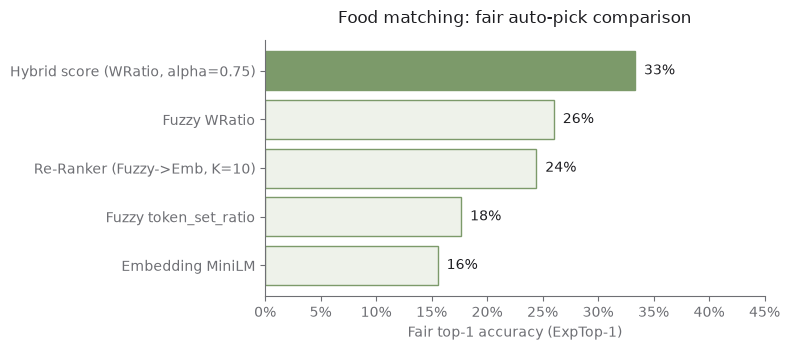

Chart saved: ml/reranker_headtohead.png


In [13]:
import matplotlib.pyplot as plt

# NutriWise corporate design: one accent (sage green), lots of whitespace, sans-serif
SAGE, SOFT, INK, INK_SOFT = "#7c9a6a", "#eef2ea", "#1d1d21", "#6e6f74"
plt.rcParams.update({"font.family": "sans-serif", "axes.edgecolor": INK_SOFT})

d = comp.sort_values("ExpTop-1")                    # ascending -> best on top in barh
best_val = d["ExpTop-1"].max()
colors = [SAGE if v == best_val else SOFT for v in d["ExpTop-1"]]

fig, ax = plt.subplots(figsize=(8, 3.6))
bars = ax.barh(d["Model"], d["ExpTop-1"], color=colors, edgecolor=SAGE, linewidth=1)
for bar, v in zip(bars, d["ExpTop-1"]):
    ax.text(v + 0.008, bar.get_y() + bar.get_height() / 2, f"{v:.0%}",
            va="center", ha="left", color=INK, fontsize=10)

ax.set_xlim(0, max(0.45, best_val + 0.08))
ax.set_xlabel("Fair top-1 accuracy (ExpTop-1)", color=INK_SOFT)
ax.set_title("Food matching: fair auto-pick comparison", color=INK, pad=12)
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.tick_params(colors=INK_SOFT)
plt.tight_layout()
plt.savefig("reranker_headtohead.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: ml/reranker_headtohead.png")

In [14]:
# Error analysis: hybrid vs. pure WRatio, row by row
hybrid_key = next(k for k in results if k.startswith("Hybrid"))
ea = pd.DataFrame({
    "query": queries,
    "gold": gold["gold_name"].tolist(),
    "WRatio_top1": results["Fuzzy WRatio"]["top1_pred"],   # argmax (first hit under ties)
    "Hybrid_top1": results[hybrid_key]["top1_pred"],
})
ea["WRatio_ok"] = ea["WRatio_top1"] == ea["gold"]
ea["Hybrid_ok"] = ea["Hybrid_top1"] == ea["gold"]

def show(df, cols=("query", "gold", "WRatio_top1", "Hybrid_top1")):
    with pd.option_context("display.max_colwidth", 34, "display.width", 200):
        print(df[list(cols)].to_string(index=False) if len(df) else "  (none)")

print("(1) Embedding HELPS — hybrid correct, pure WRatio wrong:")
show(ea[ea.Hybrid_ok & ~ea.WRatio_ok])
print("\n(2) Embedding HURTS — WRatio correct, hybrid wrong:")
show(ea[~ea.Hybrid_ok & ea.WRatio_ok])
print("\n(3) Both wrong — often 'semantically plausible, but a different name' (measurement limit):")
show(ea[~ea.Hybrid_ok & ~ea.WRatio_ok].head(8))
print(f"\nNote: WRatio_top1 is an argmax representative from often many tied candidates — the qualitative "
      f"examples are illustrative; the numbers above (ExpTop-1) are what count.")

(1) Embedding HELPS — hybrid correct, pure WRatio wrong:
        query                          gold                    WRatio_top1                   Hybrid_top1
       Gurken              Gurken gedünstet Paprika-Gurkengemüse gedünstet              Gurken gedünstet
Rispentomaten Tomaten passiert/Tomatenpüree   Omelett gebraten mit Tomaten Tomaten passiert/Tomatenpüree

(2) Embedding HURTS — WRatio correct, hybrid wrong:
      query                          gold                   WRatio_top1                      Hybrid_top1
   Brötchen           Brötchen glutenfrei           Brötchen glutenfrei                  Matjes-Brötchen
       Cola     Colagetränk koffeinhaltig     Colagetränk koffeinhaltig Colabier (Pilsner Bier mit Cola)
G&G Tomaten Tomaten passiert/Tomatenpüree Tomaten passiert/Tomatenpüree      Rührei gebraten mit Tomaten
 Gouda jung        Gouda 48 % Fett i. Tr.        Gouda 48 % Fett i. Tr.     Gouda mind. 40 % Fett i. Tr.
Hackfleisch      Schwein Hackfleisch, roh      Sch

---
## Conclusion — honest

**Result.** An *off-the-shelf* multilingual embedding model is, on this task, **not a good primary matcher,
but a useful tie-breaker.**

| Use case | Best model | Why |
|---|---|---|
| **Auto-pick** (system picks exactly 1 match) | **Hybrid score** (75% WRatio + 25% embedding) | fair top-1 **33% vs. 26%** — ~+27% relative, and *deterministic* instead of tie-rolling |
| **Shortlist** (user picks from top-3/5) | **pure Fuzzy WRatio** | R@3/R@5 = **56%**; the hybrid displaces good candidates here |
| **Standalone embedding search** | — (worst option) | generic model falls for token traps (`Cola`→`Colabier`) |

**Why the embedding alone fails (from the error analysis):**
- **Token traps:** `Cola`→`Colabier`, `AB Bud Bier`→`Biersauce` — surface words dominate the semantics.
- **Domain blindness:** a paraphrase model barely knows food nuances (raw/steamed, fat levels).
- **Where it helps:** true synonyms with no character overlap (`Rispentomaten`→`Tomaten passiert`) — exactly fuzzy's gap.

**Measurement limits (deliberately not airbrushed):**
1. **45 items** — small dataset, wide confidence intervals.
2. **α chosen on the same set** → the hybrid value is *optimistically biased*, an exploration result, not a product number.
3. **Exact-name metric** penalizes equivalent BLS alternatives (category (3): `Rote Rübe/Rote Bete, gedünstet`
   ≈ gold `Rote-Bete-Gemüse gedünstet`). The *real* usable hit rate is probably higher than measured here.
4. **No fresh judge verdicts** — we test retrieval against known gold answers, not a new quality assessment.

**Product framing (confirms the guiding principle "keep rules where they generalize"):**
Fuzzy already generalizes well here; ML only pays off as a **narrow add-on** (tie-breaker), not a replacement.
What would actually move the needle — in this order:
1. **Tier 0 "learned verified matches"** (collect user confirmations) — personalized, transparent, no model training.
2. **Domain-adapted / fine-tuned embedding** on food pairs instead of generic paraphrases.
3. **Richer query normalization** (strip quantities/brands, units) before matching.

> **For the presentation:** don't sell "our ML model improves matching", but the *honest, nuanced* story:
> we tested retrieval, re-ranking and score fusion; embeddings help as a tie-breaker on auto-pick (+27%
> relative, fairly measured), but are not a free win — in line with "honesty as a feature".